In [2]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from pathlib import Path
import re
import xml.etree.ElementTree as ET
from functools import reduce
import openpyxl
from scipy.optimize import minimize_scalar
import numpy as np
import glob

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

In [3]:
folder = Path("first_layer/data")

dfs = {}

for file_path in folder.iterdir():
    if not file_path.is_file():
        continue

    suffix = file_path.suffix.lower()

    try:
        df = pd.read_csv(file_path)

        dfs[file_path.stem] = df

    except Exception as e:
        print(f"Could not read {file_path.name}: {e}")

In [4]:
# dfs['final_labour_data'] = dfs['final_labour_data'].rename(columns={'year-quarter': 'year_quarter'})
dfs['monetary_aggregates'] = dfs['monetary_aggregates'].rename(columns={'quarter_end': 'year_quarter'})
dfs['taxes_2010_2024'] = dfs['taxes_2010_2024'].rename(columns={'year-quarter': 'year_quarter'})

In [5]:
final = dfs['taxes_2010_2024'].merge(dfs['final_labour_data'], on="year_quarter", how="left") \
    .merge(dfs['monetary_aggregates'], on="year_quarter", how="left") \
    .merge(dfs['indicators_with_school_enrollment'], on="year_quarter", how="left") \
    .merge(dfs['quarterly_electricity'], on="year_quarter", how="left") \
    .merge(dfs['rates_2010_2024'], on="year_quarter", how="left") \
    .merge(dfs['quarterly_nominal_gdp'], on="year_quarter", how="left")

final

,year_quarter,tax_revenue,total_expense,internal_taxes_goods_services,employed_percent_of_population_respective_age_group,employed_people_thousands,unemployed_percent_of_population_respective_age_group,unemployed_people_thousands,labour_force_percent_of_population_respective_age_group,labour_force_people_thousands,informal_employed_15_70_thousands,Population,M0,M1,M2,school_enrollment_q_interp,Rule of law index (-2.5 weak; 2.5 strong),Government effectiveness index (-2.5 weak; 2.5 strong),Corruption Perceptions Index 100 = no corruption,Fiscal freedom index (0-100),Business freedom index (0-100),Financial freedom index (0-100),Economic freedom overall index (0-100),electricity,log_electricity,dlog_electricity,usd_avg_q,eur_avg_q,interest_rate_avg_q,cpi_base_2010,nominal_gdp,gdp_s21,gdp_2
0,2010Q1,6.376784e+10,7.318785e+10,1.815880e+10,65.6,0.0,8.8,0.0,72.0,0.0,NaN,45962900.0,1.539822e+11,2.275528e+11,4.780519e+11,82.351502,-0.81,-0.81,24,78.0,39.0,30.0,46.0,3.233018e+07,17.291512,NaN,7.987706,11.072078,10.250000,94.766667,2.708323e+11,1.341048e+12,2.170740e+11
1,2010Q2,6.553761e+10,8.408957e+10,1.919947e+10,65.6,0.0,8.8,0.0,72.0,0.0,NaN,45962900.0,1.621290e+11,2.492082e+11,5.199940e+11,82.203752,-0.81,-0.81,24,78.0,39.0,30.0,46.0,3.347838e+07,17.326410,0.034899,7.922431,10.101016,10.058333,95.166667,2.626266e+11,1.364544e+12,2.555450e+11
2,2010Q3,7.124160e+10,6.325354e+10,2.156587e+10,65.6,0.0,8.8,0.0,72.0,0.0,NaN,45962900.0,1.751030e+11,2.713026e+11,5.553273e+11,82.056001,-0.81,-0.81,24,78.0,39.0,30.0,46.0,3.375625e+07,17.334676,0.008266,7.900627,10.175621,8.147833,96.166667,2.668010e+11,1.380542e+12,3.004460e+11
3,2010Q4,7.745295e+10,1.038390e+11,2.267587e+10,65.6,0.0,8.8,0.0,72.0,0.0,NaN,45962900.0,1.733323e+11,2.763735e+11,5.726598e+11,81.908251,-0.81,-0.81,24,78.0,39.0,30.0,46.0,3.448258e+07,17.355965,0.021289,7.931368,10.785121,7.750000,99.366667,2.790862e+11,1.399885e+12,3.062810e+11
4,2011Q1,7.304560e+10,8.450490e+10,3.624400e+10,66.5,0.0,8.6,0.0,72.7,0.0,NaN,45778500.0,1.775604e+11,2.867065e+11,6.030967e+11,82.630715,-0.77,-0.83,23,77.0,47.0,30.0,46.0,3.480440e+07,17.365254,0.009289,7.944952,10.849500,7.750000,102.066667,3.034000e+11,1.428757e+12,2.585910e+11
5,2011Q2,8.066000e+10,1.030898e+11,3.815560e+10,66.5,0.0,8.6,0.0,72.7,0.0,NaN,45778500.0,1.846835e+11,3.006278e+11,6.327842e+11,83.353179,-0.77,-0.83,23,77.0,47.0,30.0,46.0,3.477870e+07,17.364516,-0.000739,7.970973,11.476876,7.750000,105.366667,3.219657e+11,1.431777e+12,3.102770e+11
6,2011Q3,8.871570e+10,9.944910e+10,4.581030e+10,66.5,0.0,8.6,0.0,72.7,0.0,NaN,45778500.0,1.939773e+11,3.111016e+11,6.610108e+11,84.075642,-0.77,-0.83,23,77.0,47.0,30.0,46.0,3.537074e+07,17.381396,0.016880,7.971707,11.277828,7.750000,104.300000,3.325906e+11,1.456604e+12,3.684880e+11
7,2011Q4,9.227060e+10,1.298098e+11,4.380310e+10,66.5,0.0,8.6,0.0,72.7,0.0,NaN,45778500.0,1.841643e+11,2.948371e+11,6.502994e+11,84.798106,-0.77,-0.83,23,77.0,47.0,30.0,46.0,3.487364e+07,17.367242,-0.014154,7.982770,10.764995,7.750000,104.400000,3.420346e+11,1.468721e+12,3.626350e+11
8,2012Q1,8.356080e+10,9.899970e+10,3.969200e+10,67.1,0.0,8.1,0.0,73.0,0.0,NaN,45633600.0,1.864667e+11,3.000397e+11,6.762243e+11,84.568554,-0.67,-0.70,26,78.0,46.0,30.0,46.0,3.385493e+07,17.337595,-0.029647,7.988155,10.457435,7.725800,105.033333,3.488093e+11,1.450569e+12,2.923240e+11
9,2012Q2,9.264270e+10,1.179240e+11,4.622200e+10,67.1,0.0,8.1,0.0,73.0,0.0,NaN,45633600.0,1.948008e+11,3.136343e+11,6.948994e+11,84.339003,-0.67,-0.70,26,78.0,46.0,30.0,46.0,3.499055e+07,17.370589,0.032994,7.990008,10.262791,7.500000,105.000000,3.477758e+11,1.458445e+12,3.460050e+11


<Axes: title={'center': 'Quarterly Nominal GDP'}, xlabel='year_quarter'>

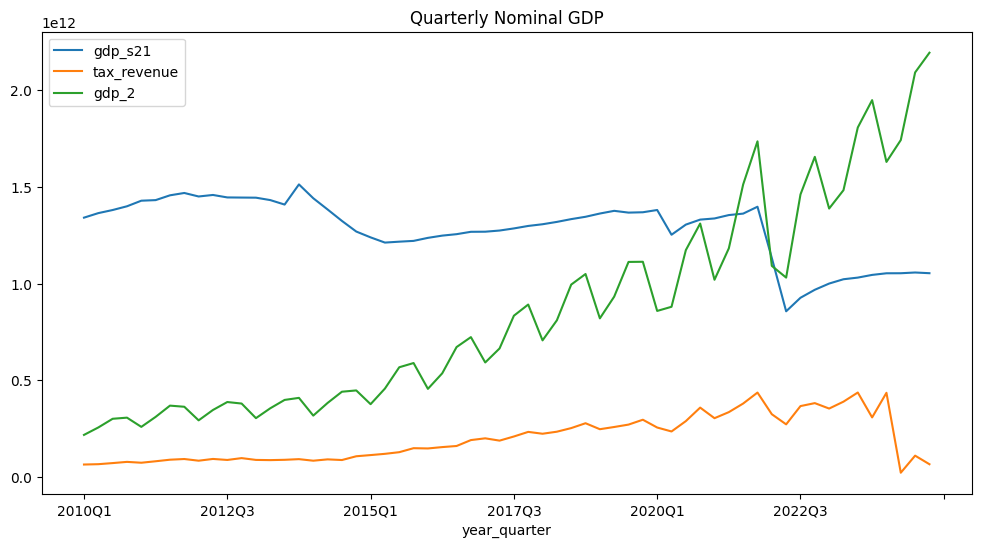

In [6]:
final.plot(x="year_quarter", y=["gdp_s21", 'tax_revenue', 'gdp_2'], kind="line", figsize=(12, 6), title="Quarterly Nominal GDP")

# Calculations

In [7]:
## Scaling
cols_to_scale = ['Rule of law index (-2.5 weak; 2.5 strong)', 'Government effectiveness index (-2.5 weak; 2.5 strong)']

for col in cols_to_scale:
    final[f"{col}"] = ((final[col] + 2.5) / 5) * 100

## Renaming long names to shorter ones for better readability
final = final.rename(columns={'Rule of law index (-2.5 weak; 2.5 strong)': 'rule_of_law',
                                'Government effectiveness index (-2.5 weak; 2.5 strong)': 'government_effectiveness',
                                'Corruption Perceptions Index 100 = no corruption': 'corruption_perceptions',
                                'Business freedom index (0-100)': 'business_freedom',
                                'Fiscal freedom index (0-100)': 'fiscal_freedom',
                                'Economic freedom overall index (0-100)': 'economic_freedom',
                                'employed_percent_of_population_respective_age_group': 'employment',
                                'unemployed_percent_of_population_respective_age_group': 'unemployment',
                                'labour_force_percent_of_population_respective_age_group': 'lfp_rate',
                                'internal_taxes_goods_services': 'indirect_tax',
                                'school_enrollment_q_interp': 'schooling',})

In [8]:
final.head(1)

,year_quarter,tax_revenue,total_expense,indirect_tax,employment,employed_people_thousands,unemployment,unemployed_people_thousands,lfp_rate,labour_force_people_thousands,informal_employed_15_70_thousands,Population,M0,M1,M2,schooling,rule_of_law,government_effectiveness,corruption_perceptions,fiscal_freedom,business_freedom,Financial freedom index (0-100),economic_freedom,electricity,log_electricity,dlog_electricity,usd_avg_q,eur_avg_q,interest_rate_avg_q,cpi_base_2010,nominal_gdp,gdp_s21,gdp_2
0,2010Q1,6.376784e+10,7.318785e+10,1.815880e+10,65.6,0.0,8.8,0.0,72.0,0.0,NaN,45962900.0,1.539822e+11,2.275528e+11,4.780519e+11,82.351502,33.8,33.8,24,78.0,39.0,30.0,46.0,3.233018e+07,17.291512,NaN,7.987706,11.072078,10.25,94.766667,2.708323e+11,1.341048e+12,2.170740e+11


In [9]:
## Deflator
final['2021_deflator'] = (final['gdp_s21'] / final['gdp_2']) * 100

## Metrix
final['tax_burden'] = (final['tax_revenue'] / final['gdp_2']) * 100
final['direct_tax_share'] = (1 - (final['indirect_tax'] / final['tax_revenue'])) * 100
final['gov_expenditure_share'] = (final['total_expense'] / final['gdp_2']) * 100
final['deflated_tax_revenue'] = (final['tax_revenue'] / final['2021_deflator']) * 100

## GDP related
final['gdp_per_capita'] = final['gdp_s21'] / final['Population']

## Cash related
final['cash_demand'] = final['M0'] / final['M2']
final['deflated_M1'] = (final['M1'] / final['2021_deflator']) * 100

## Labour related
final['unemployment_rate'] = (final['unemployment'] / final['lfp_rate']) * 100
final['employment_rate'] = (final['employment'] / final['lfp_rate']) * 100
# final['unofficial_employment_rate'] = final['informal_employed_15_70_thousands'] / final['employed_people_thousands']

## Electricity related
final['electricity_consumptions'] = (final['electricity'] / final['gdp_2']) * 100


In [10]:
final.columns

Index(['year_quarter', 'tax_revenue', 'total_expense', 'indirect_tax',
       'employment', 'employed_people_thousands', 'unemployment',
       'unemployed_people_thousands', 'lfp_rate',
       'labour_force_people_thousands', 'informal_employed_15_70_thousands',
       'Population', 'M0', 'M1', 'M2', 'schooling', 'rule_of_law',
       'government_effectiveness', 'corruption_perceptions', 'fiscal_freedom',
       'business_freedom', 'Financial freedom index (0-100)',
       'economic_freedom', 'electricity', 'log_electricity',
       'dlog_electricity', 'usd_avg_q', 'eur_avg_q', 'interest_rate_avg_q',
       'cpi_base_2010', 'nominal_gdp', 'gdp_s21', 'gdp_2', '2021_deflator',
       'tax_burden', 'direct_tax_share', 'gov_expenditure_share',
       'deflated_tax_revenue', 'gdp_per_capita', 'cash_demand', 'deflated_M1',
       'unemployment_rate', 'employment_rate', 'electricity_consumptions'],
      dtype='object')

In [11]:
final.to_csv('data/pre_gold.csv')

# Forming useful dataset

In [12]:
gold = final[["year_quarter", "gdp_s21", 'gdp_2', 'gdp_per_capita',
              'schooling', 'rule_of_law',
              'government_effectiveness', 'corruption_perceptions', 'fiscal_freedom',
              'business_freedom', 'economic_freedom',
              'usd_avg_q', 'eur_avg_q', 'interest_rate_avg_q',
              'tax_burden', 'direct_tax_share', 'gov_expenditure_share', 'deflated_tax_revenue',
              'cash_demand', 'deflated_M1', 'unemployment_rate', 'employment_rate', 'lfp_rate',
              'electricity_consumptions', 'electricity'
              ]].copy()
gold

,year_quarter,gdp_s21,gdp_2,gdp_per_capita,schooling,rule_of_law,government_effectiveness,corruption_perceptions,fiscal_freedom,business_freedom,economic_freedom,usd_avg_q,eur_avg_q,interest_rate_avg_q,tax_burden,direct_tax_share,gov_expenditure_share,deflated_tax_revenue,cash_demand,deflated_M1,unemployment_rate,employment_rate,lfp_rate,electricity_consumptions,electricity
0,2010Q1,1.341048e+12,2.170740e+11,29176.749074,82.351502,33.8,33.8,24,78.0,39.0,46.0,7.987706,11.072078,10.250000,29.376082,71.523580,33.715621,1.032203e+10,0.322104,3.683373e+10,12.222222,91.111111,72.0,0.014894,3.233018e+07
1,2010Q2,1.364544e+12,2.555450e+11,29687.943972,82.203752,33.8,33.8,24,78.0,39.0,46.0,7.922431,10.101016,10.058333,25.646212,70.704659,32.905972,1.227356e+10,0.311790,4.667047e+10,12.222222,91.111111,72.0,0.013101,3.347838e+07
2,2010Q3,1.380542e+12,3.004460e+11,30036.007302,82.056001,33.8,33.8,24,78.0,39.0,46.0,7.900627,10.175621,8.147833,23.711947,69.728546,21.053213,1.550424e+10,0.315315,5.904332e+10,12.222222,91.111111,72.0,0.011235,3.375625e+07
3,2010Q4,1.399885e+12,3.062810e+11,30456.846718,81.908251,33.8,33.8,24,78.0,39.0,46.0,7.931368,10.785121,7.750000,25.288201,70.723042,33.903197,1.694594e+10,0.302679,6.046779e+10,12.222222,91.111111,72.0,0.011258,3.448258e+07
4,2011Q1,1.428757e+12,2.585910e+11,31210.218771,82.630715,34.6,33.4,23,77.0,47.0,46.0,7.944952,10.849500,7.750000,28.247541,50.381679,32.678980,1.322054e+10,0.294415,5.189106e+10,11.829436,91.471802,72.7,0.013459,3.480440e+07
5,2011Q2,1.431777e+12,3.102770e+11,31276.188604,83.353179,34.6,33.4,23,77.0,47.0,46.0,7.970973,11.476876,7.750000,25.996126,52.695760,33.225086,1.747964e+10,0.291859,6.514835e+10,11.829436,91.471802,72.7,0.011209,3.477870e+07
6,2011Q3,1.456604e+12,3.684880e+11,31818.517426,84.075642,34.6,33.4,23,77.0,47.0,46.0,7.971707,11.277828,7.750000,24.075601,48.362804,26.988423,2.244307e+10,0.293456,7.870169e+10,11.829436,91.471802,72.7,0.009599,3.537074e+07
7,2011Q4,1.468721e+12,3.626350e+11,32083.204998,84.798106,34.6,33.4,23,77.0,47.0,46.0,7.982770,10.764995,7.750000,25.444483,52.527566,35.796269,2.278210e+10,0.283199,7.279685e+10,11.829436,91.471802,72.7,0.009617,3.487364e+07
8,2012Q1,1.450569e+12,2.923240e+11,31787.301462,84.568554,36.6,36.0,26,78.0,46.0,46.0,7.988155,10.457435,7.725800,28.584995,52.499258,33.866429,1.683948e+10,0.275747,6.046511e+10,11.095890,91.917808,73.0,0.011581,3.385493e+07
9,2012Q2,1.458445e+12,3.460050e+11,31959.893587,84.339003,36.6,36.0,26,78.0,46.0,46.0,7.990008,10.262791,7.500000,26.774960,50.107240,34.081588,2.197878e+10,0.280329,7.440736e+10,11.095890,91.917808,73.0,0.010113,3.499055e+07


In [13]:
gold.to_csv('data/gold_data.csv')

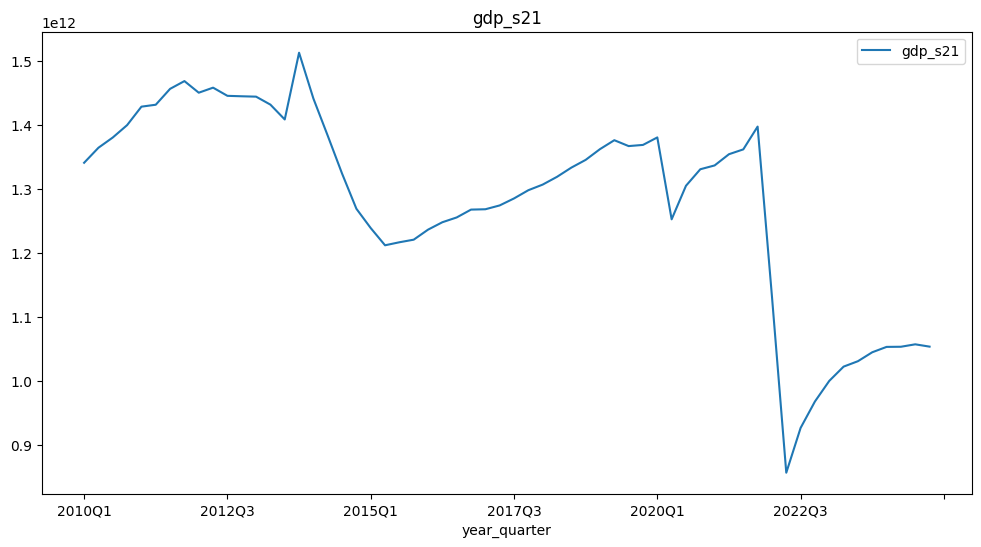

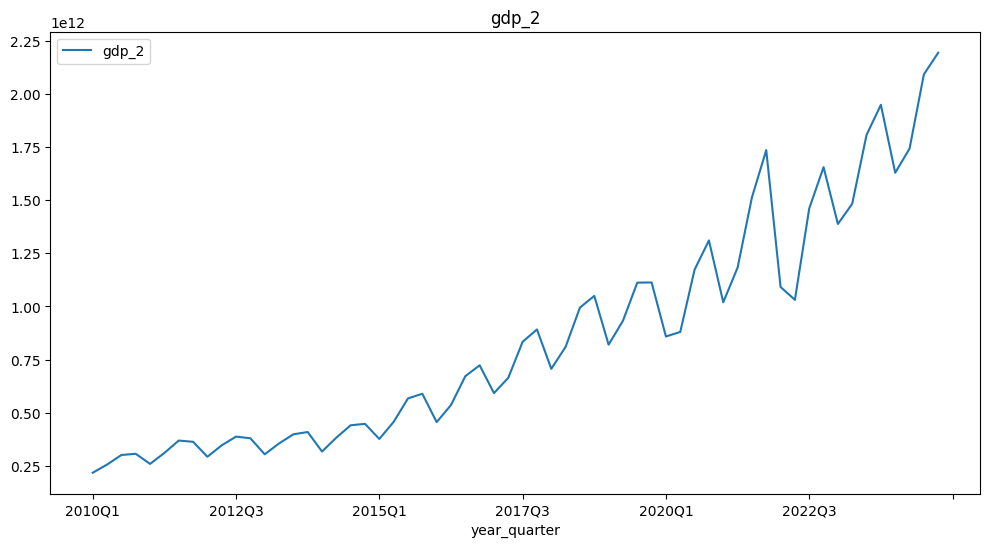

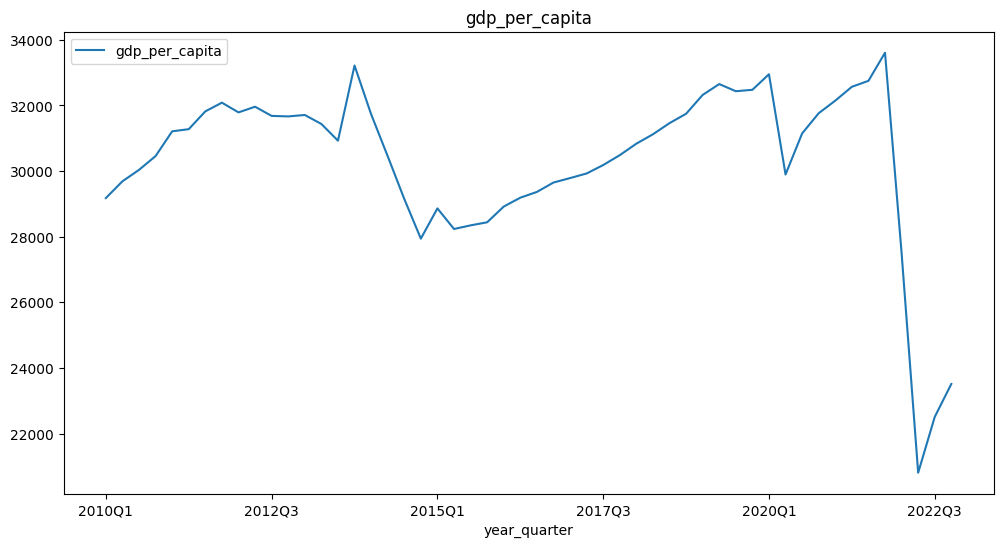

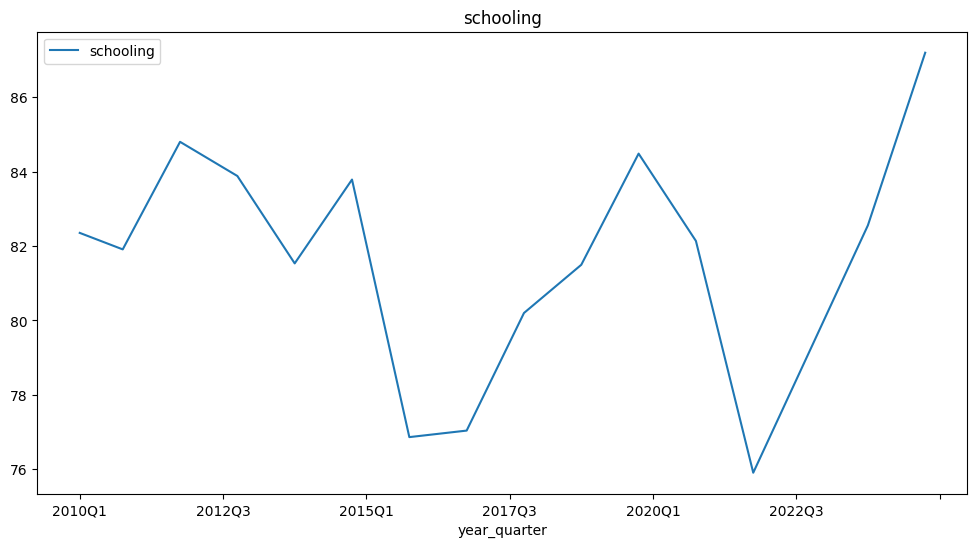

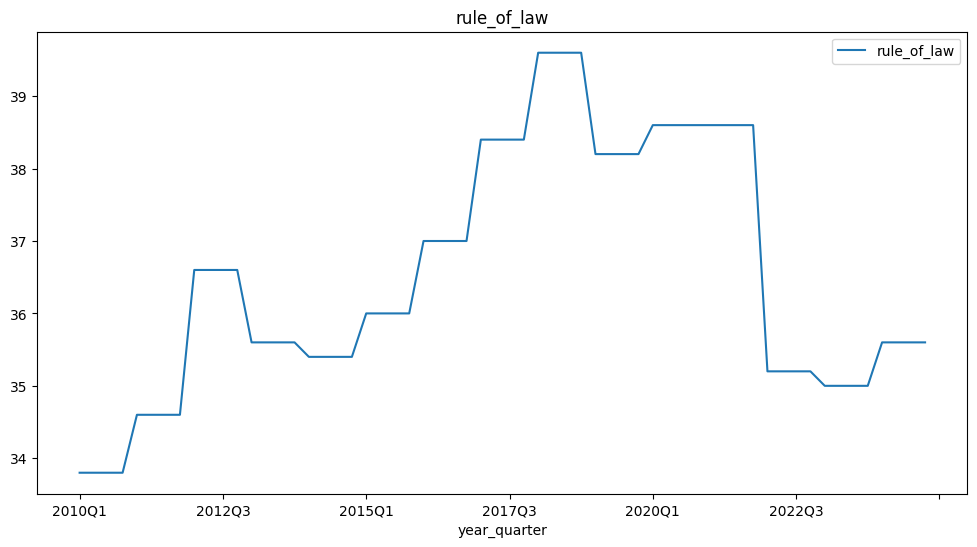

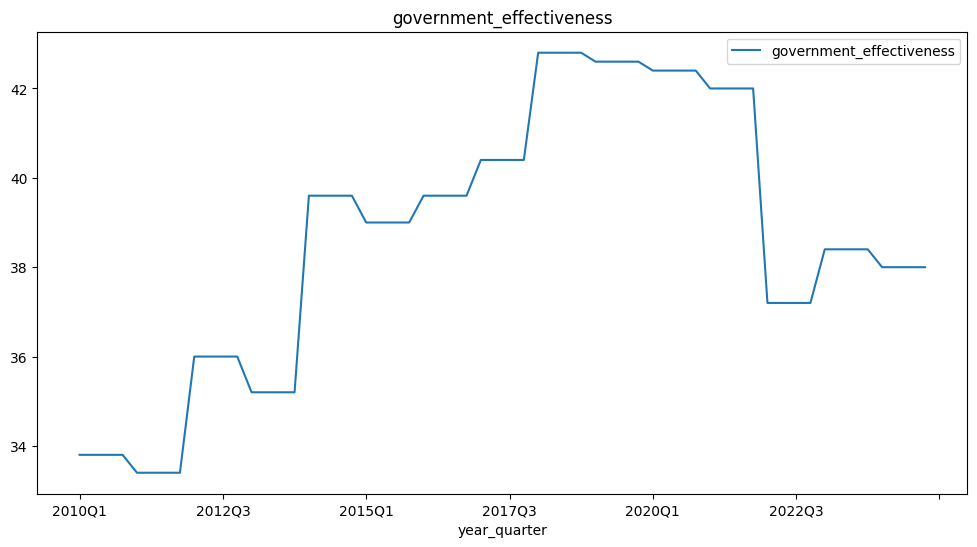

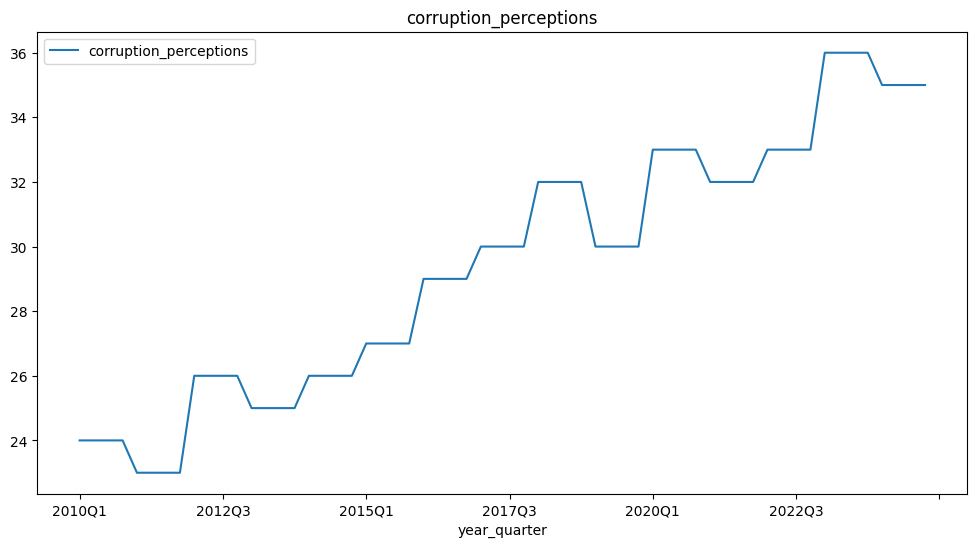

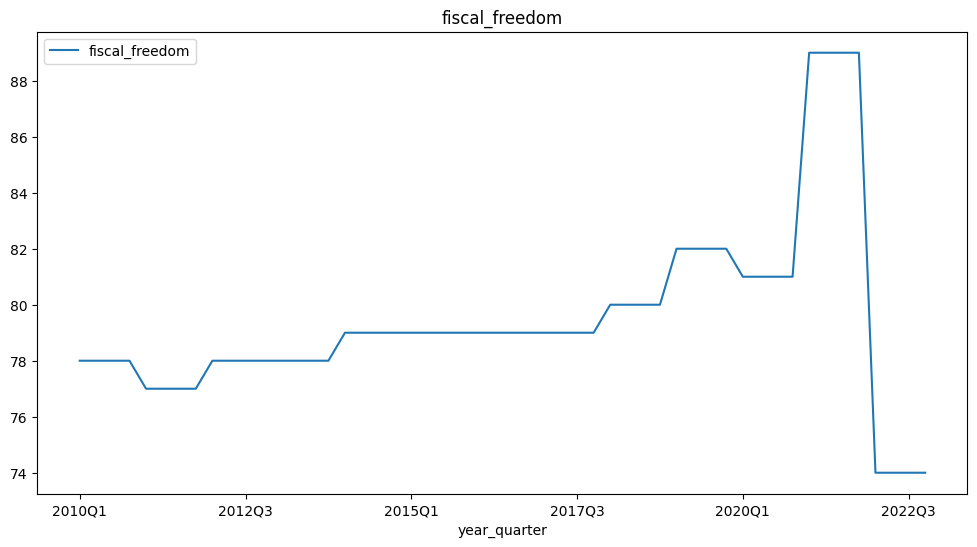

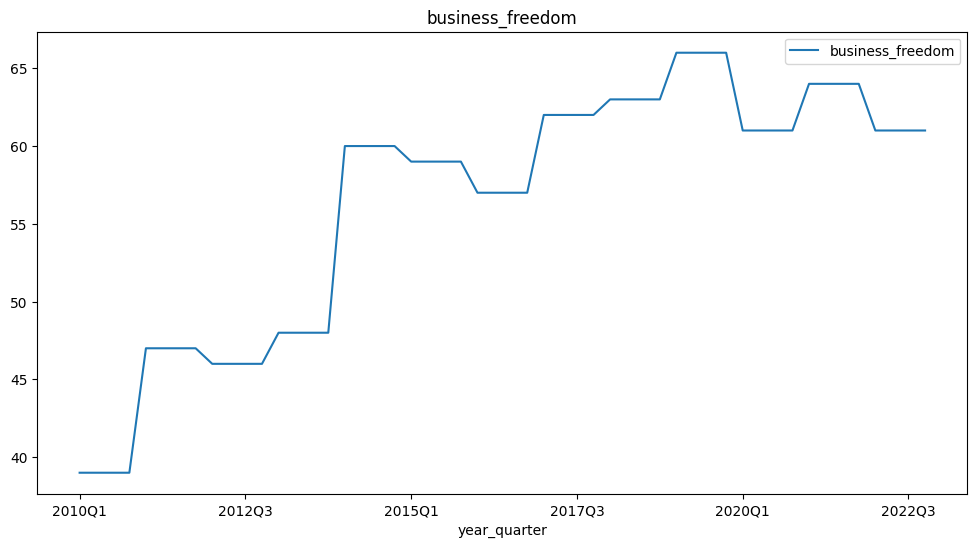

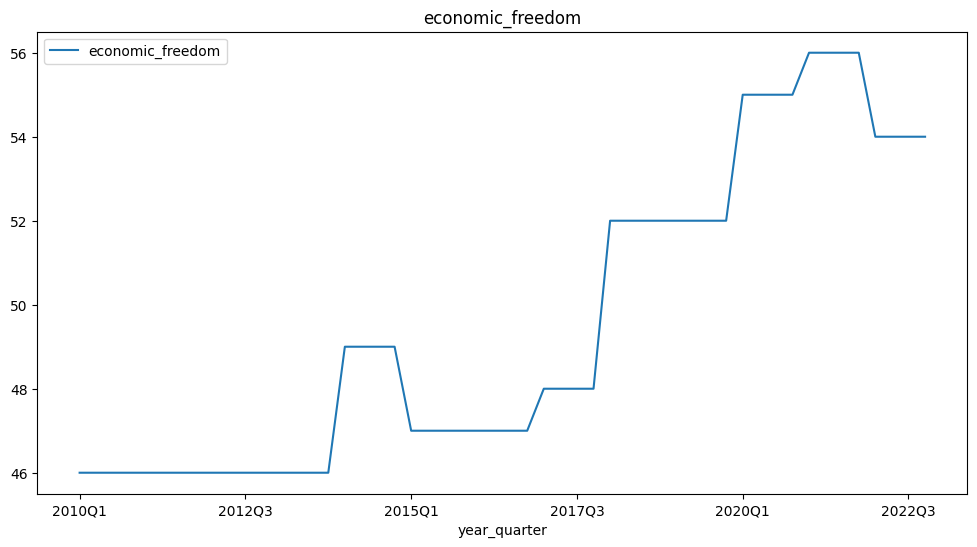

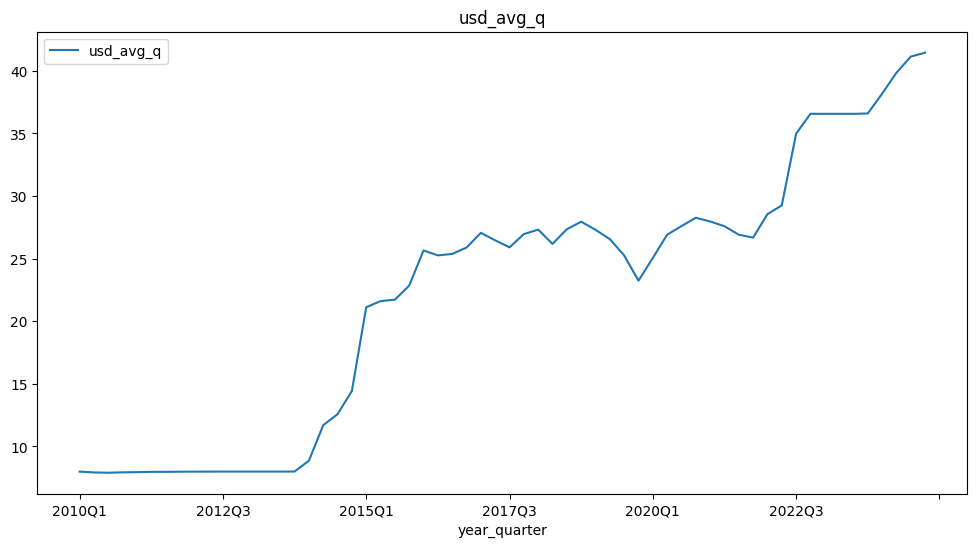

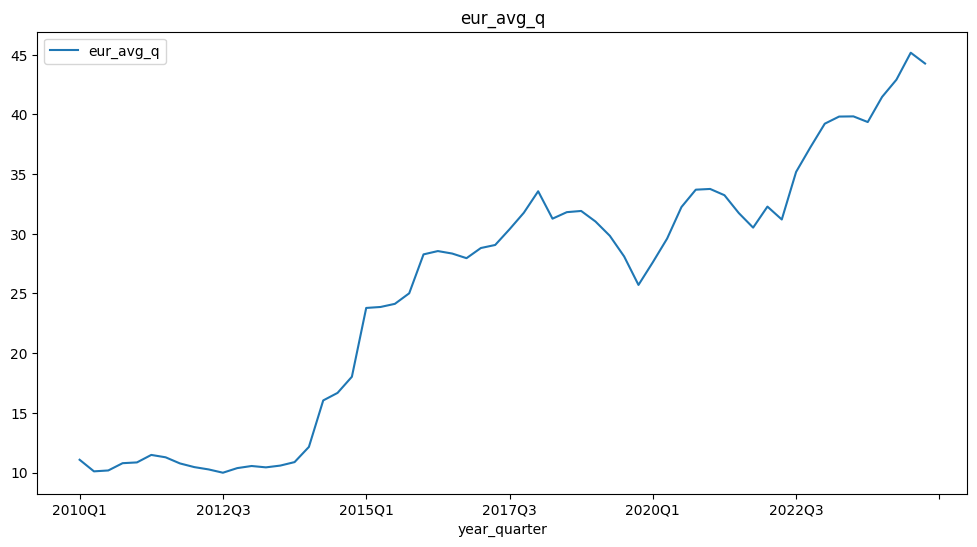

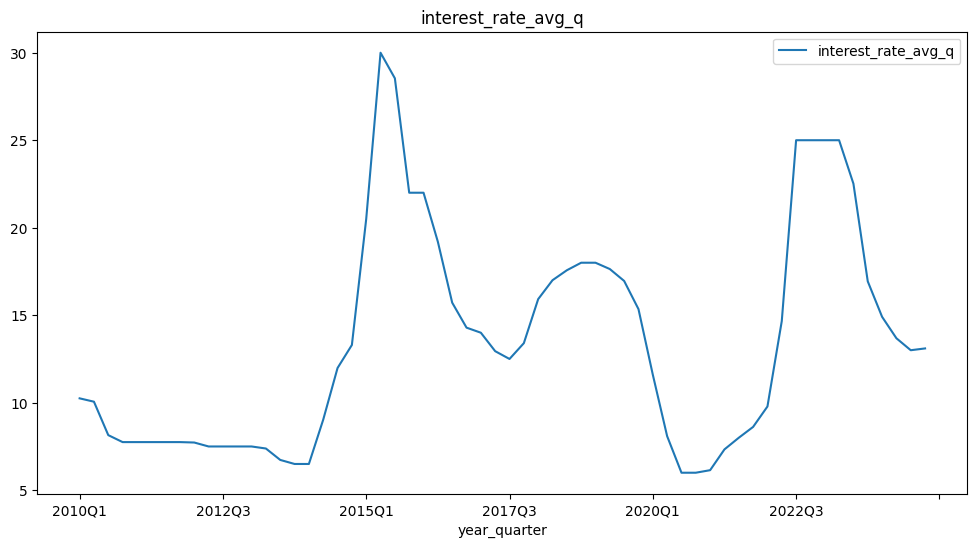

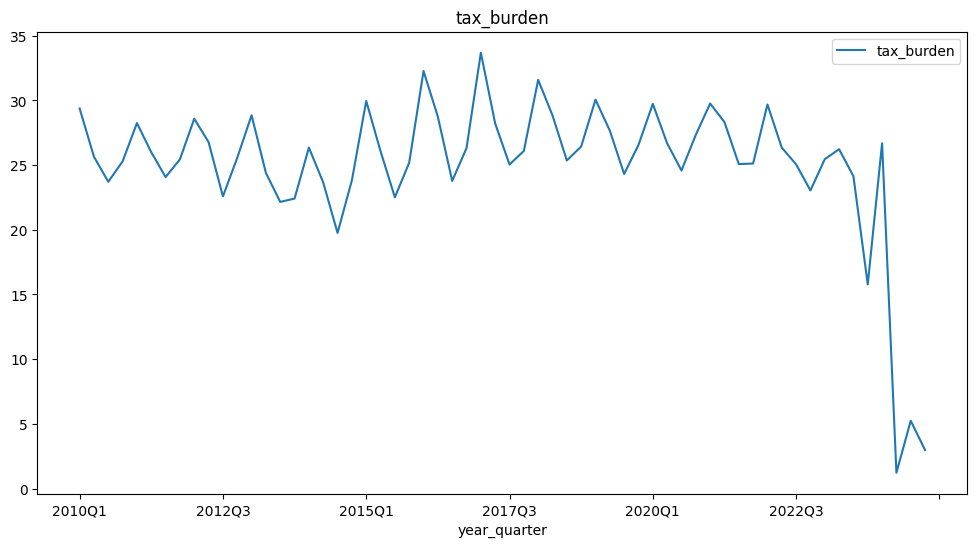

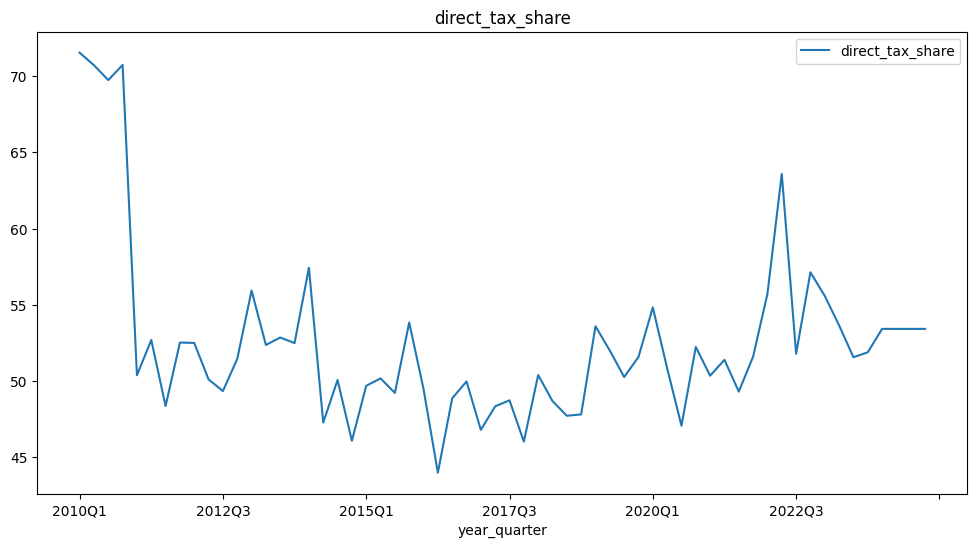

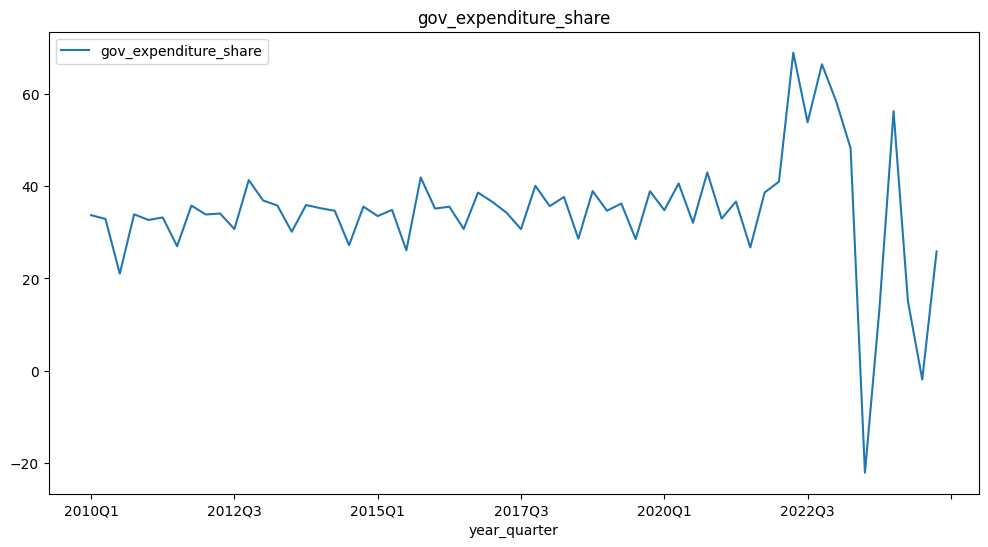

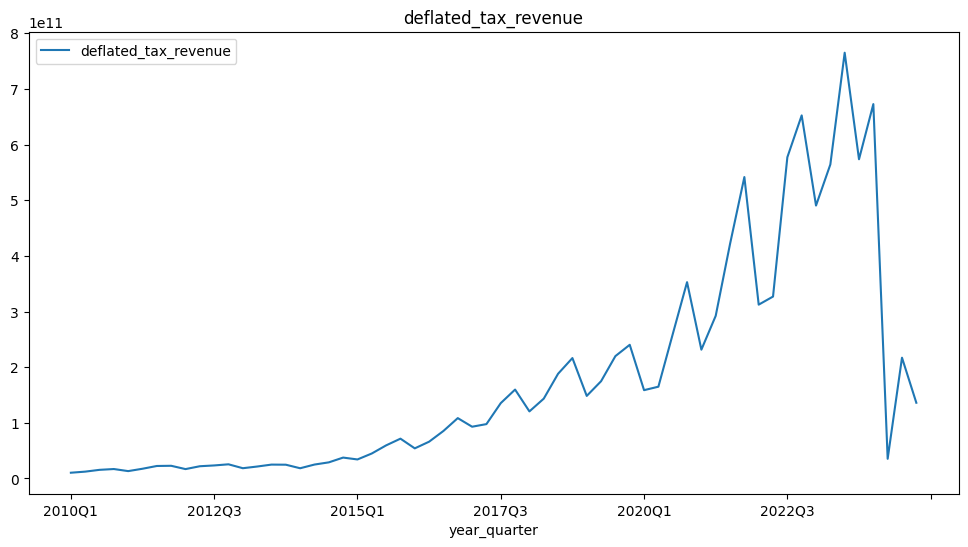

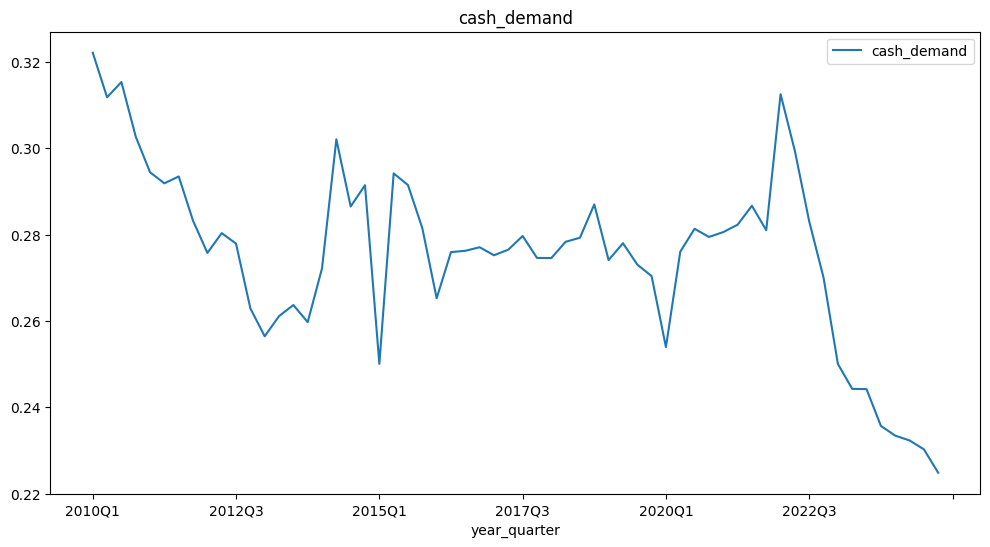

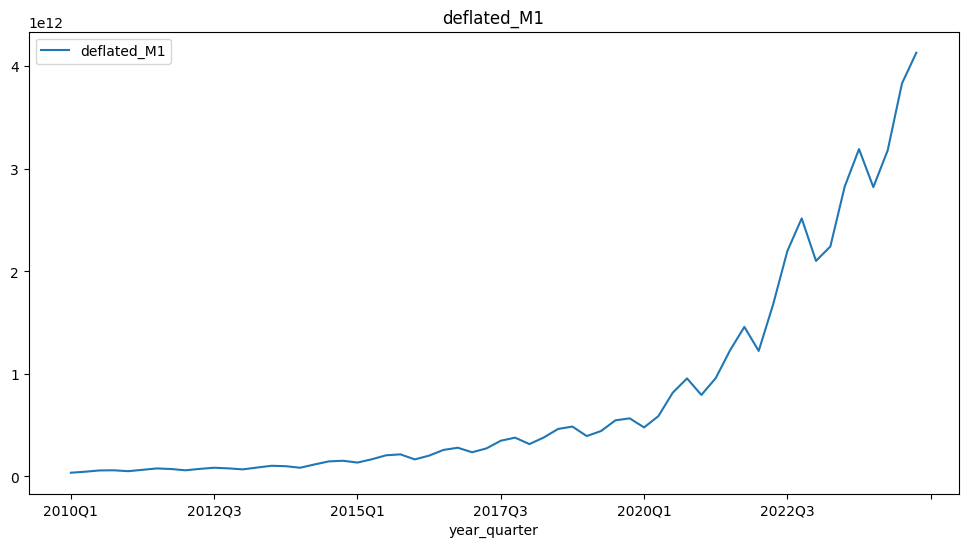

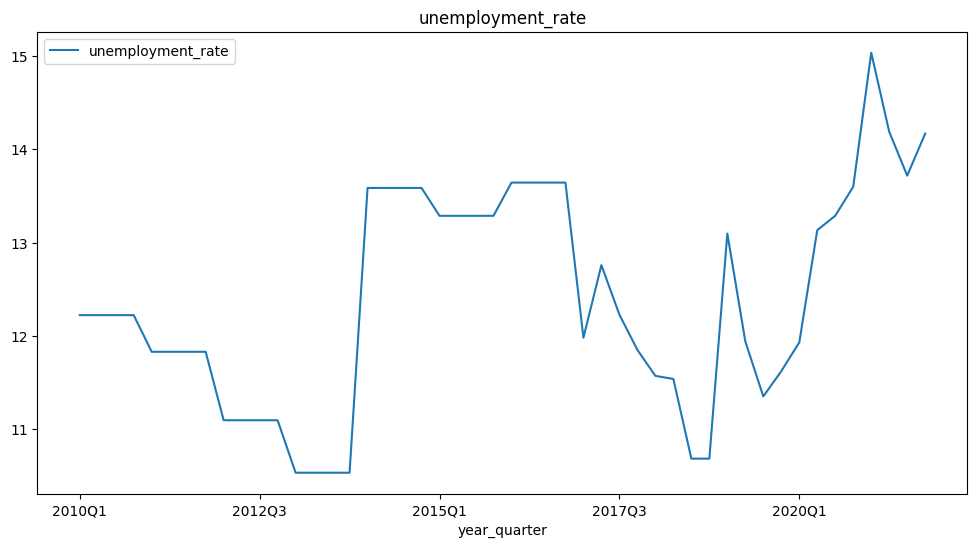

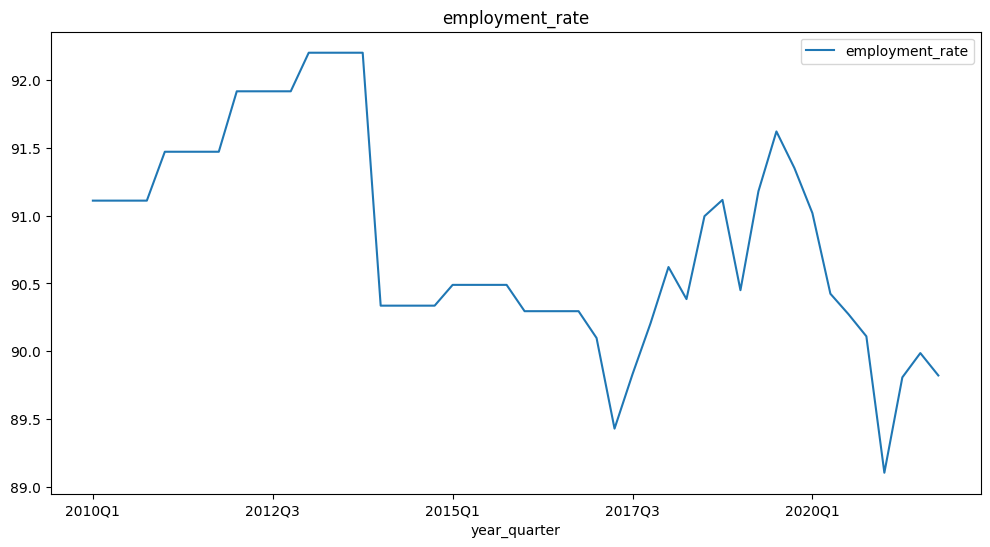

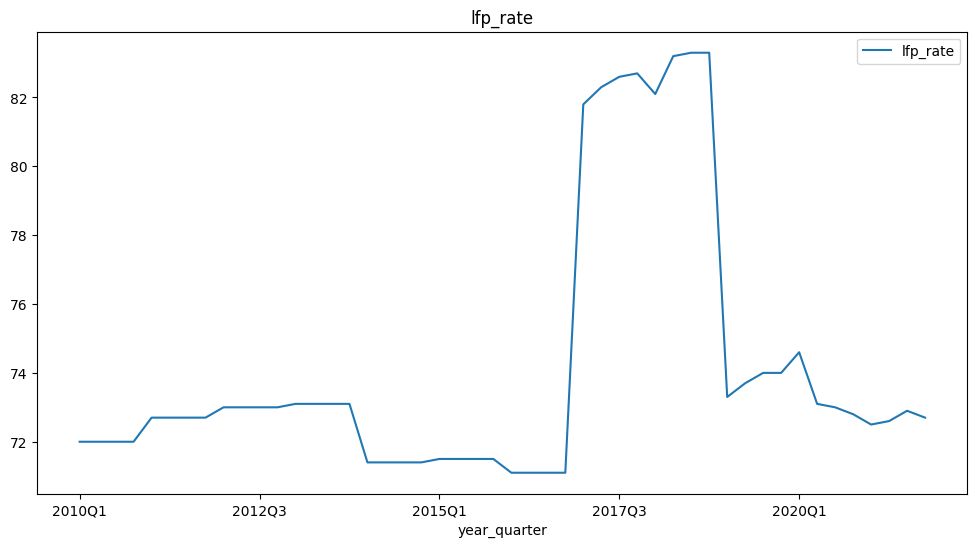

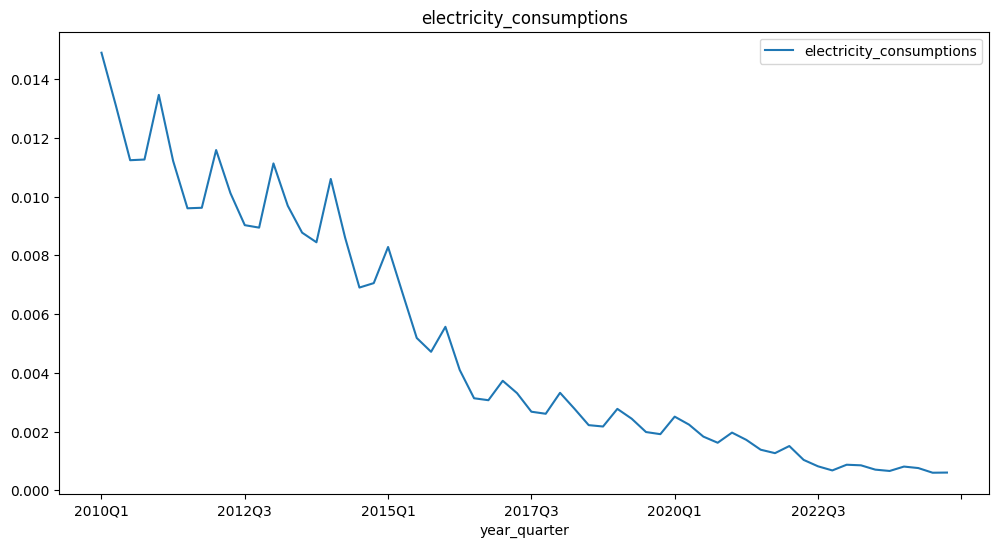

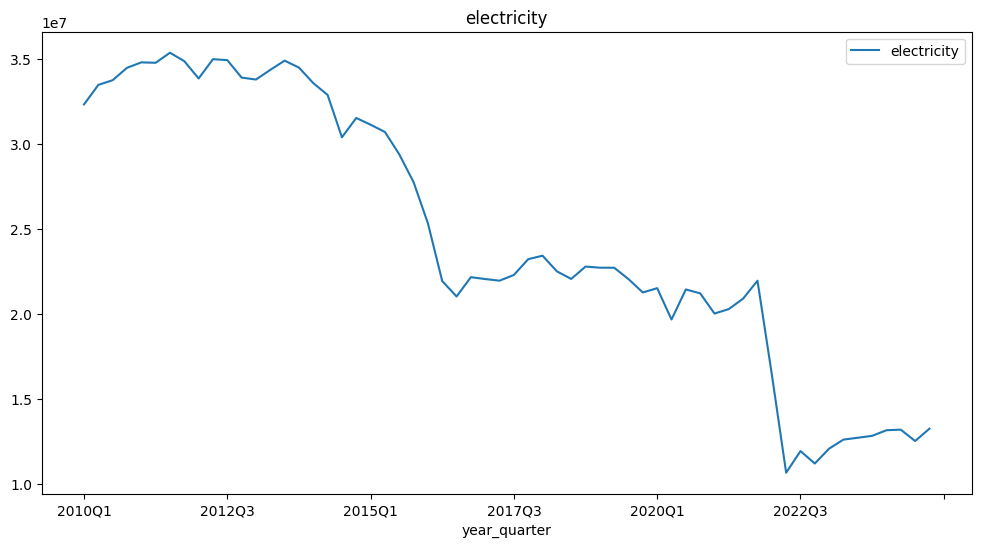

In [14]:
for col in gold.columns:
    if col != "year_quarter":
        gold.plot(x="year_quarter", y=col, kind="line", figsize=(12, 6), title=col)

In [15]:
gold

,year_quarter,gdp_s21,gdp_2,gdp_per_capita,schooling,rule_of_law,government_effectiveness,corruption_perceptions,fiscal_freedom,business_freedom,economic_freedom,usd_avg_q,eur_avg_q,interest_rate_avg_q,tax_burden,direct_tax_share,gov_expenditure_share,deflated_tax_revenue,cash_demand,deflated_M1,unemployment_rate,employment_rate,lfp_rate,electricity_consumptions,electricity
0,2010Q1,1.341048e+12,2.170740e+11,29176.749074,82.351502,33.8,33.8,24,78.0,39.0,46.0,7.987706,11.072078,10.250000,29.376082,71.523580,33.715621,1.032203e+10,0.322104,3.683373e+10,12.222222,91.111111,72.0,0.014894,3.233018e+07
1,2010Q2,1.364544e+12,2.555450e+11,29687.943972,82.203752,33.8,33.8,24,78.0,39.0,46.0,7.922431,10.101016,10.058333,25.646212,70.704659,32.905972,1.227356e+10,0.311790,4.667047e+10,12.222222,91.111111,72.0,0.013101,3.347838e+07
2,2010Q3,1.380542e+12,3.004460e+11,30036.007302,82.056001,33.8,33.8,24,78.0,39.0,46.0,7.900627,10.175621,8.147833,23.711947,69.728546,21.053213,1.550424e+10,0.315315,5.904332e+10,12.222222,91.111111,72.0,0.011235,3.375625e+07
3,2010Q4,1.399885e+12,3.062810e+11,30456.846718,81.908251,33.8,33.8,24,78.0,39.0,46.0,7.931368,10.785121,7.750000,25.288201,70.723042,33.903197,1.694594e+10,0.302679,6.046779e+10,12.222222,91.111111,72.0,0.011258,3.448258e+07
4,2011Q1,1.428757e+12,2.585910e+11,31210.218771,82.630715,34.6,33.4,23,77.0,47.0,46.0,7.944952,10.849500,7.750000,28.247541,50.381679,32.678980,1.322054e+10,0.294415,5.189106e+10,11.829436,91.471802,72.7,0.013459,3.480440e+07
5,2011Q2,1.431777e+12,3.102770e+11,31276.188604,83.353179,34.6,33.4,23,77.0,47.0,46.0,7.970973,11.476876,7.750000,25.996126,52.695760,33.225086,1.747964e+10,0.291859,6.514835e+10,11.829436,91.471802,72.7,0.011209,3.477870e+07
6,2011Q3,1.456604e+12,3.684880e+11,31818.517426,84.075642,34.6,33.4,23,77.0,47.0,46.0,7.971707,11.277828,7.750000,24.075601,48.362804,26.988423,2.244307e+10,0.293456,7.870169e+10,11.829436,91.471802,72.7,0.009599,3.537074e+07
7,2011Q4,1.468721e+12,3.626350e+11,32083.204998,84.798106,34.6,33.4,23,77.0,47.0,46.0,7.982770,10.764995,7.750000,25.444483,52.527566,35.796269,2.278210e+10,0.283199,7.279685e+10,11.829436,91.471802,72.7,0.009617,3.487364e+07
8,2012Q1,1.450569e+12,2.923240e+11,31787.301462,84.568554,36.6,36.0,26,78.0,46.0,46.0,7.988155,10.457435,7.725800,28.584995,52.499258,33.866429,1.683948e+10,0.275747,6.046511e+10,11.095890,91.917808,73.0,0.011581,3.385493e+07
9,2012Q2,1.458445e+12,3.460050e+11,31959.893587,84.339003,36.6,36.0,26,78.0,46.0,46.0,7.990008,10.262791,7.500000,26.774960,50.107240,34.081588,2.197878e+10,0.280329,7.440736e+10,11.095890,91.917808,73.0,0.010113,3.499055e+07


# Tests

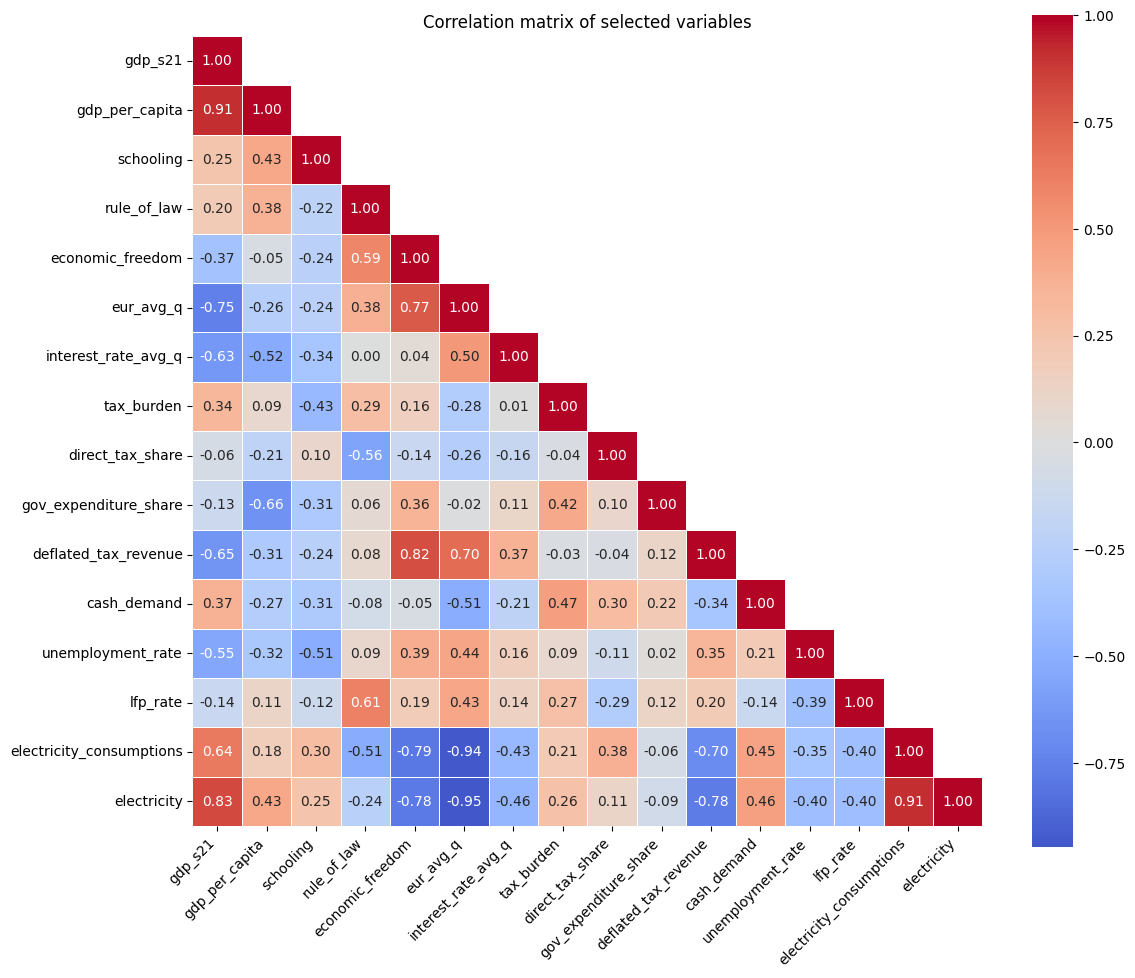

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns

df_plot = gold[[col for col in gold.columns if col not in ["year_quarter", 'deflated_M1', 'gdp_2', 'usd_avg_q', 'business_freedom', 'fiscal_freedom', 'government_effectiveness', 'corruption_perceptions', 'employment_rate']]].copy()
corr_matrix = df_plot.corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation matrix of selected variables")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, ccf, grangercausalitytests, zivot_andrews
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, breaks_cusumolsresid
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR
from statsmodels.tools.tools import add_constant
from statsmodels.formula.api import ols
from statsmodels.tsa.stattools import coint
from scipy.stats import shapiro

from semopy import Model
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from arch.unitroot import PhillipsPerron
from pmdarima.arima.utils import nsdiffs

In [18]:
cols = [col for col in gold.columns if col != "year_quarter"]

results_stationarity = []

for col in cols:
    s = gold[col].dropna()

    if len(s) < 10:
        continue

    # ADF
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag="AIC")

    # KPSS
    kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")

    # PP
    pp = PhillipsPerron(s)
    pp_p = pp.pvalue

    results_stationarity.append({
        "variable": col,
        "adf_p": adf_p,
        "pp_p": pp_p,
        "kpss_p": kpss_p
    })

stationarity_df = pd.DataFrame(results_stationarity)
stationarity_df

/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_54761/1945191605.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_54761/1945191605.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_54761/1945191605.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipy

,variable,adf_p,pp_p,kpss_p
0,gdp_s21,0.439866,0.668738,0.010000
1,gdp_2,1.000000,0.996117,0.010000
2,gdp_per_capita,0.122529,0.484562,0.100000
3,schooling,0.047943,0.472493,0.100000
4,rule_of_law,0.343607,0.313587,0.076888
5,government_effectiveness,0.382851,0.394298,0.017281
6,corruption_perceptions,0.817633,0.902027,0.010000
7,fiscal_freedom,0.992514,0.205413,0.087287
8,business_freedom,0.236194,0.127273,0.010000
9,economic_freedom,0.836170,0.861391,0.010000


In [19]:
def classify_stationarity(adf_p, pp_p, kpss_p, alpha=0.05):
    adf_stat = adf_p < alpha
    pp_stat = pp_p < alpha
    kpss_stat = kpss_p > alpha

    if adf_stat and pp_stat and kpss_stat:
        return "stationary"
    elif (not adf_stat) and (not pp_stat) and (not kpss_stat):
        return "non-stationary"
    else:
        return "inconclusive"

stationarity_df["classification"] = stationarity_df.apply(
    lambda r: classify_stationarity(r["adf_p"], r["pp_p"], r["kpss_p"]),
    axis=1
)

stationarity_df.sort_values("classification")

,variable,adf_p,pp_p,kpss_p,classification
21,lfp_rate,0.304510,0.276091,0.100000,inconclusive
2,gdp_per_capita,0.122529,0.484562,0.100000,inconclusive
3,schooling,0.047943,0.472493,0.100000,inconclusive
4,rule_of_law,0.343607,0.313587,0.076888,inconclusive
19,unemployment_rate,0.259146,0.218449,0.100000,inconclusive
7,fiscal_freedom,0.992514,0.205413,0.087287,inconclusive
16,deflated_tax_revenue,0.034453,0.148928,0.010000,inconclusive
15,gov_expenditure_share,0.228703,0.000005,0.100000,inconclusive
12,interest_rate_avg_q,0.004236,0.412625,0.100000,inconclusive
13,tax_burden,0.976947,0.029231,0.099679,inconclusive


In [ ]:
ocsb_results = []

for col in cols:
    s = gold[col].dropna()

    if len(s) < 12:
        continue

    try:
        D = nsdiffs(s, m=4, test="ocsb")
        ocsb_results.append({
            "variable": col,
            "suggested_seasonal_diffs": D
        })
    except:
        pass

ocsb_df = pd.DataFrame(ocsb_results)
ocsb_df.sort_values("suggested_seasonal_diffs", ascending=False)

,variable,suggested_seasonal_diffs
1,gdp_2,1
18,deflated_M1,1
13,tax_burden,1
0,gdp_s21,0
22,electricity_consumptions,0
21,lfp_rate,0
20,employment_rate,0
19,unemployment_rate,0
17,cash_demand,0
16,deflated_tax_revenue,0


<Axes: xlabel='year_quarter'>

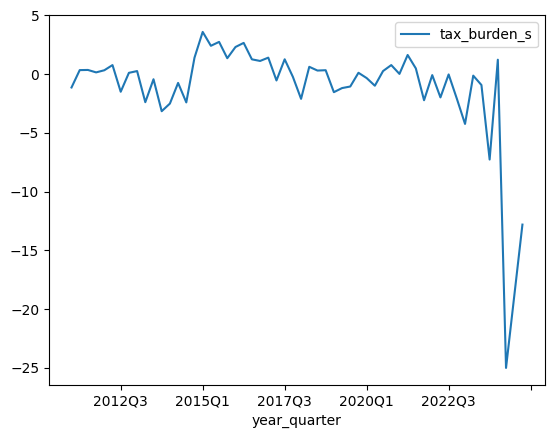

In [21]:
gold['tax_burden_s'] = gold['tax_burden'].diff(4)

gold.plot(x='year_quarter', y='tax_burden_s')

In [22]:
za_results = []
cols = [c for c in gold.columns if c != 'year-quarter']

for col in cols:
    s = gold[col].dropna()

    if len(s) < 20:
        continue

    try:
        za_stat, za_p, cv, baselag, bp = zivot_andrews(s, maxlag=4)
        za_results.append({
            "variable": col,
            "za_p": za_p,
            "break_index": bp
        })
    except:
        pass

za_df = pd.DataFrame(za_results)
za_df.sort_values('break_index')

,variable,za_p,break_index
20,employment_rate,0.309304,15
8,business_freedom,0.057284,15
12,interest_rate_avg_q,0.028689,16
22,electricity_consumptions,0.072533,16
14,direct_tax_share,0.090697,16
10,usd_avg_q,0.830420,18
3,schooling,0.291474,19
23,electricity,0.537753,21
6,corruption_perceptions,0.000880,23
21,lfp_rate,0.492359,27


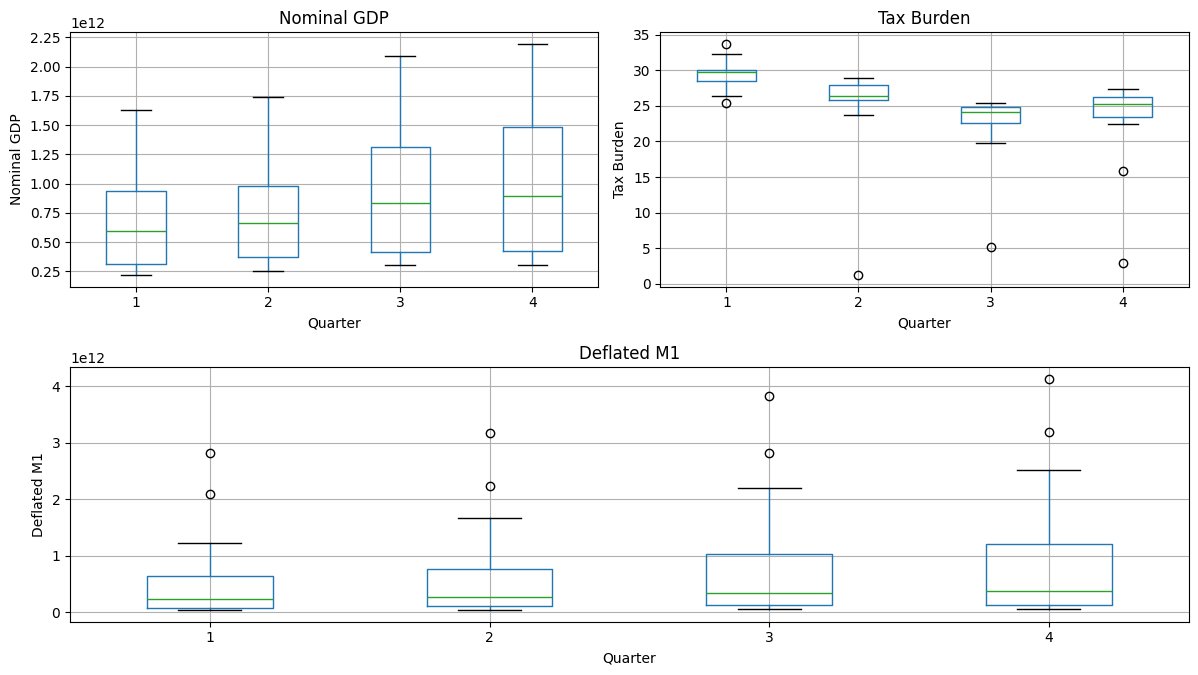

In [23]:
seasonal_vars = ocsb_df[ocsb_df['suggested_seasonal_diffs'] == 1]['variable'].to_list()

name_map = {
    "gdp_2": "Nominal GDP",
    "tax_burden": "Tax Burden",
    "deflated_M1": "Deflated M1",
}

df_plot = gold.copy()
df_plot["quarter"] = pd.PeriodIndex(df_plot["year_quarter"], freq="Q").quarter

fig = plt.figure(figsize=(12, 7))

for i, col in enumerate(seasonal_vars[:2]):
    ax = fig.add_subplot(2, 2, i + 1)
    df_plot.boxplot(column=col, by="quarter", ax=ax)
    ax.set_title(name_map.get(col, col))
    ax.set_xlabel("Quarter")
    ax.set_ylabel(name_map.get(col, col))

ax = fig.add_subplot(2, 2, (3, 4))
df_plot.boxplot(column=seasonal_vars[2], by="quarter", ax=ax)
ax.set_title(name_map.get(seasonal_vars[2], seasonal_vars[2]))
ax.set_xlabel("Quarter")
ax.set_ylabel(name_map.get(seasonal_vars[2], seasonal_vars[2]))

plt.suptitle("")
plt.tight_layout()
plt.show()

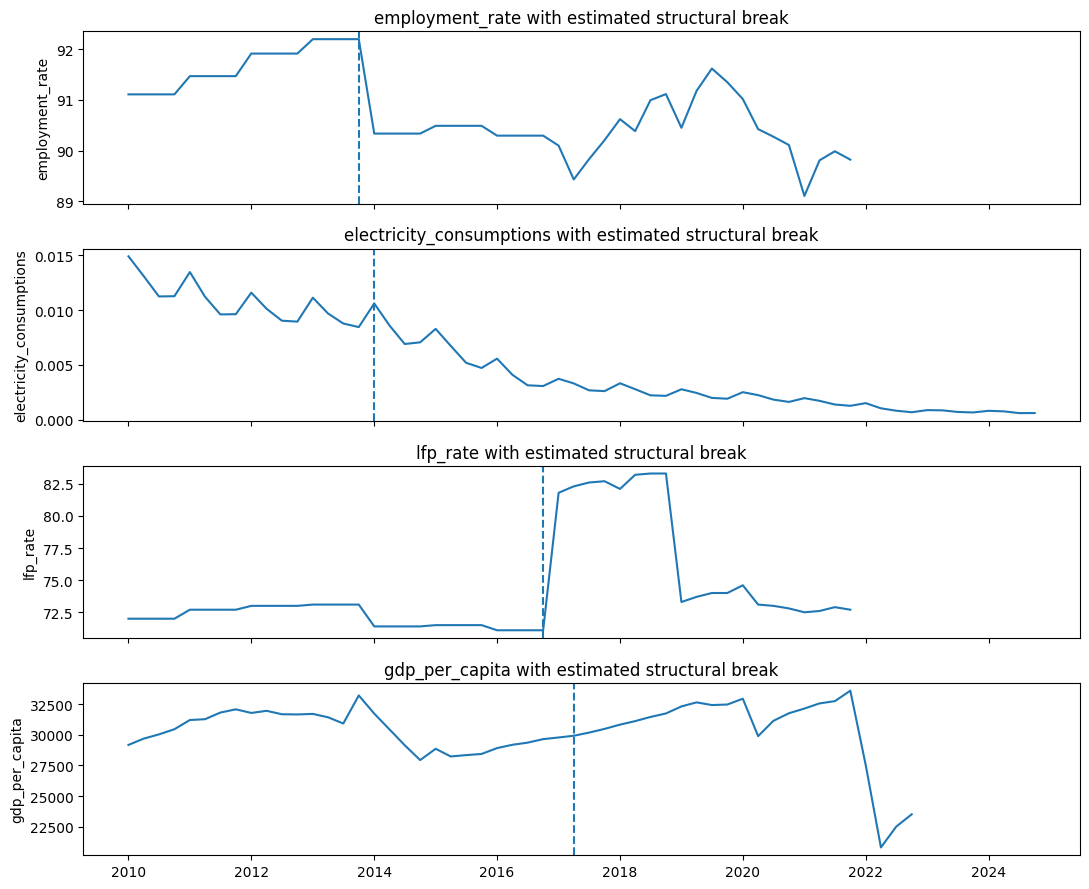

In [24]:
df_plot["date"] = pd.PeriodIndex(df_plot["year_quarter"], freq="Q").to_timestamp()

break_vars = ["employment_rate", "electricity_consumptions", "lfp_rate", "gdp_per_capita"]

break_indices = {
    "employment_rate": 15,
    "electricity_consumptions": 16,
    "gdp_per_capita": 29,
    "lfp_rate": 27
}

fig, axes = plt.subplots(
    nrows=len(break_vars),
    ncols=1,
    figsize=(11, 9),
    sharex=True
)

for ax, col in zip(axes, break_vars):
    ax.plot(df_plot["date"], df_plot[col])
    
    break_idx = break_indices[col]
    break_date = df_plot.iloc[break_idx]["date"]
    
    ax.axvline(break_date, linestyle="--")
    ax.set_title(f"{col} with estimated structural break")
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# Data prep

In [25]:
gold = gold[gold['year_quarter'] <= '2021Q4'].copy()

In [26]:
positive_level_vars = [
    'deflated_tax_revenue',
    "gdp_s21",
    'gdp_per_capita',
    "usd_avg_q",
    "eur_avg_q"
]

rate_share_vars = [
    "tax_burden",
    "direct_tax_share",
    "gov_expenditure_share",
    "unemployment_rate",
    "employment_rate",
    "lfp_rate",
    "cash_demand",
    "interest_rate_avg_q"
]

institutional_vars = [
    "schooling",
    "rule_of_law",
    "government_effectiveness",
    "corruption_perceptions",
    "fiscal_freedom",
    "business_freedom",
    "economic_freedom"
]

In [27]:
for col in positive_level_vars:
    gold[col] = pd.to_numeric(gold[col], errors="coerce")
    
    if (gold[col] > 0).all():
        gold[f"log_{col}"] = np.log(gold[col])
        gold[f"dlog_{col}"] = gold[f"log_{col}"].diff()
    else:
        print(f"Skipped log for {col}: contains zero or negative values")

for col in institutional_vars:
    gold[col] = pd.to_numeric(gold[col], errors="coerce")
    gold[f"d_{col}"] = gold[col].diff()

In [28]:
for col in rate_share_vars:
    gold[col] = pd.to_numeric(gold[col], errors="coerce")
    gold[f"d_{col}"] = gold[col].diff()

In [29]:
seasonal_vars = [
    "deflated_M1",
    "tax_burden",
    "gdp_2"
]

seasonal_vars = [c for c in seasonal_vars if c in gold.columns]

for col in seasonal_vars:
    gold[f"sdiff_{col}"] = gold[col].diff(4)
    
    if f"log_{col}" in gold.columns:
        gold[f"sdiff_log_{col}"] = gold[f"log_{col}"].diff(4)

In [30]:
def stationarity_tests(series):
    s = pd.to_numeric(series, errors="coerce").dropna()
    
    if len(s) < 10:
        return {
            "adf_p": np.nan,
            "pp_p": np.nan,
            "kpss_p": np.nan,
            "classification": "too few observations"
        }
    try:
        adf_p = adfuller(s, autolag="AIC")[1]
    except:
        adf_p = np.nan
    
    try:
        pp_p = PhillipsPerron(s).pvalue
    except:
        pp_p = np.nan
    
    try:
        kpss_p = kpss(s, regression="c", nlags="auto")[1]
    except:
        kpss_p = np.nan
    
    if adf_p < 0.05 and pp_p < 0.05 and kpss_p > 0.05:
        classification = "stationary"
    elif adf_p >= 0.05 and pp_p >= 0.05 and kpss_p <= 0.05:
        classification = "non-stationary"
    else:
        classification = "mixed"
    
    return {
        "adf_p": adf_p,
        "pp_p": pp_p,
        "kpss_p": kpss_p,
        "classification": classification
    }

In [31]:
cols = [col for col in gold.columns if col != "year_quarter"]

results_stationarity = []

for col in cols:
    s = gold[col].dropna()

    if len(s) < 10:
        continue

    # ADF
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag="AIC")

    # KPSS
    kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")

    # PP
    pp = PhillipsPerron(s)
    pp_p = pp.pvalue

    results_stationarity.append({
        "variable": col,
        "adf_p": adf_p,
        "pp_p": pp_p,
        "kpss_p": kpss_p
    })

stationarity_df = pd.DataFrame(results_stationarity)
stationarity_df

def classify_stationarity(adf_p, pp_p, kpss_p, alpha=0.05):
    adf_stat = adf_p < alpha
    pp_stat = pp_p < alpha
    kpss_stat = kpss_p > alpha

    if adf_stat and pp_stat and kpss_stat:
        return "stationary"
    elif (not adf_stat) and (not pp_stat) and (not kpss_stat):
        return "non-stationary"
    else:
        return "inconclusive"

stationarity_df["classification"] = stationarity_df.apply(
    lambda r: classify_stationarity(r["adf_p"], r["pp_p"], r["kpss_p"]),
    axis=1
)

stationarity_df.sort_values("classification")

/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_54761/2811164438.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_54761/2811164438.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipykernel_54761/2811164438.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
/var/folders/44/_kgb4vyn4l766wp3pn98bp3h0000gn/T/ipy

,variable,adf_p,pp_p,kpss_p,classification
0,gdp_s21,5.594921e-01,4.067741e-01,0.100000,inconclusive
42,d_tax_burden,1.130723e-01,4.941522e-20,0.100000,inconclusive
39,d_fiscal_freedom,8.255540e-01,7.501678e-10,0.100000,inconclusive
38,d_corruption_perceptions,2.149370e-01,2.401232e-12,0.100000,inconclusive
35,d_schooling,2.328925e-01,3.049051e-01,0.100000,inconclusive
32,dlog_usd_avg_q,2.865463e-01,5.739655e-05,0.100000,inconclusive
29,log_gdp_per_capita,4.613010e-01,3.274879e-01,0.100000,inconclusive
27,log_gdp_s21,5.729867e-01,4.157896e-01,0.100000,inconclusive
21,lfp_rate,3.045104e-01,2.760907e-01,0.100000,inconclusive
19,unemployment_rate,2.591461e-01,2.184490e-01,0.100000,inconclusive


In [32]:
def suggest_variable_form(base_var, df_tests):
    candidates = [
        base_var,
        f"log_{base_var}",
        f"d_{base_var}",
        f"dlog_{base_var}",
        f"sdiff_{base_var}",
        f"sdiff_log_{base_var}"
    ]
    
    existing = df_tests[df_tests["variable"].isin(candidates)].copy()
    
    if existing.empty:
        return None
    
    stationary = existing[existing["classification"] == "stationary"]
    
    if not stationary.empty:
        order = {
            base_var: 1,
            f"log_{base_var}": 2,
            f"d_{base_var}": 3,
            f"dlog_{base_var}": 4,
            f"sdiff_{base_var}": 5,
            f"sdiff_log_{base_var}": 6
        }
        stationary["priority"] = stationary["variable"].map(order)
        return stationary.sort_values("priority").iloc[0]["variable"]
    
    mixed = existing[existing["classification"] == "mixed"]
    
    if not mixed.empty:
        return mixed.iloc[0]["variable"]
    
    return existing.iloc[0]["variable"]

In [33]:
base_vars = positive_level_vars + rate_share_vars + institutional_vars

recommendations = []

for var in base_vars:
    recommended = suggest_variable_form(var, stationarity_df)
    recommendations.append({
        "original_variable": var,
        "recommended_form": recommended
    })

recommended_forms = pd.DataFrame(recommendations)
recommended_forms

,original_variable,recommended_form
0,deflated_tax_revenue,deflated_tax_revenue
1,gdp_s21,dlog_gdp_s21
2,gdp_per_capita,dlog_gdp_per_capita
3,usd_avg_q,usd_avg_q
4,eur_avg_q,dlog_eur_avg_q
5,tax_burden,sdiff_tax_burden
6,direct_tax_share,d_direct_tax_share
7,gov_expenditure_share,d_gov_expenditure_share
8,unemployment_rate,d_unemployment_rate
9,employment_rate,d_employment_rate


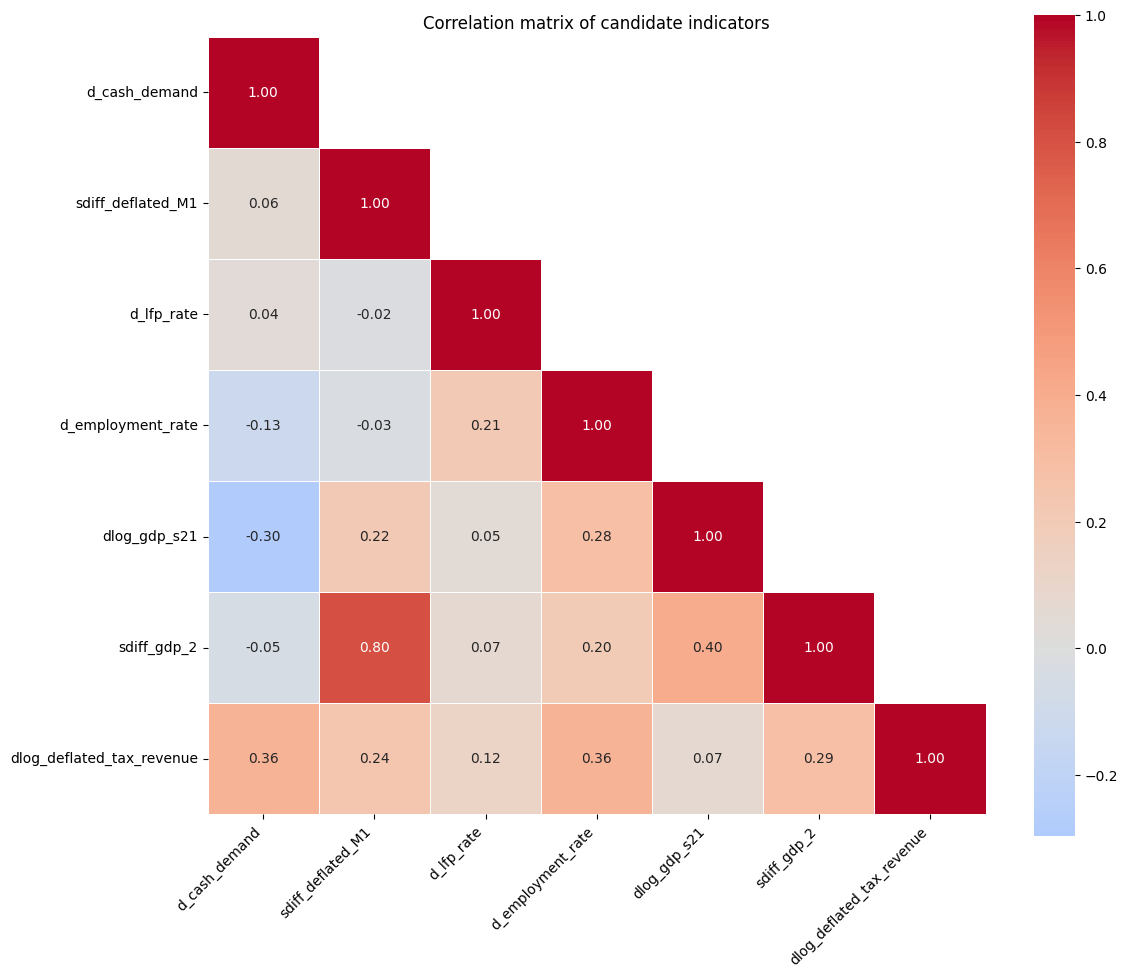

In [34]:
candidate_indicators = [
    "d_cash_demand",
    "sdiff_deflated_M1",
    "d_lfp_rate",
    "d_employment_rate",
    "dlog_gdp_s21",
    "sdiff_gdp_2",
    "dlog_deflated_tax_revenue"
]

df_plot = gold[candidate_indicators].copy()
corr_matrix = df_plot.corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation matrix of candidate indicators")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

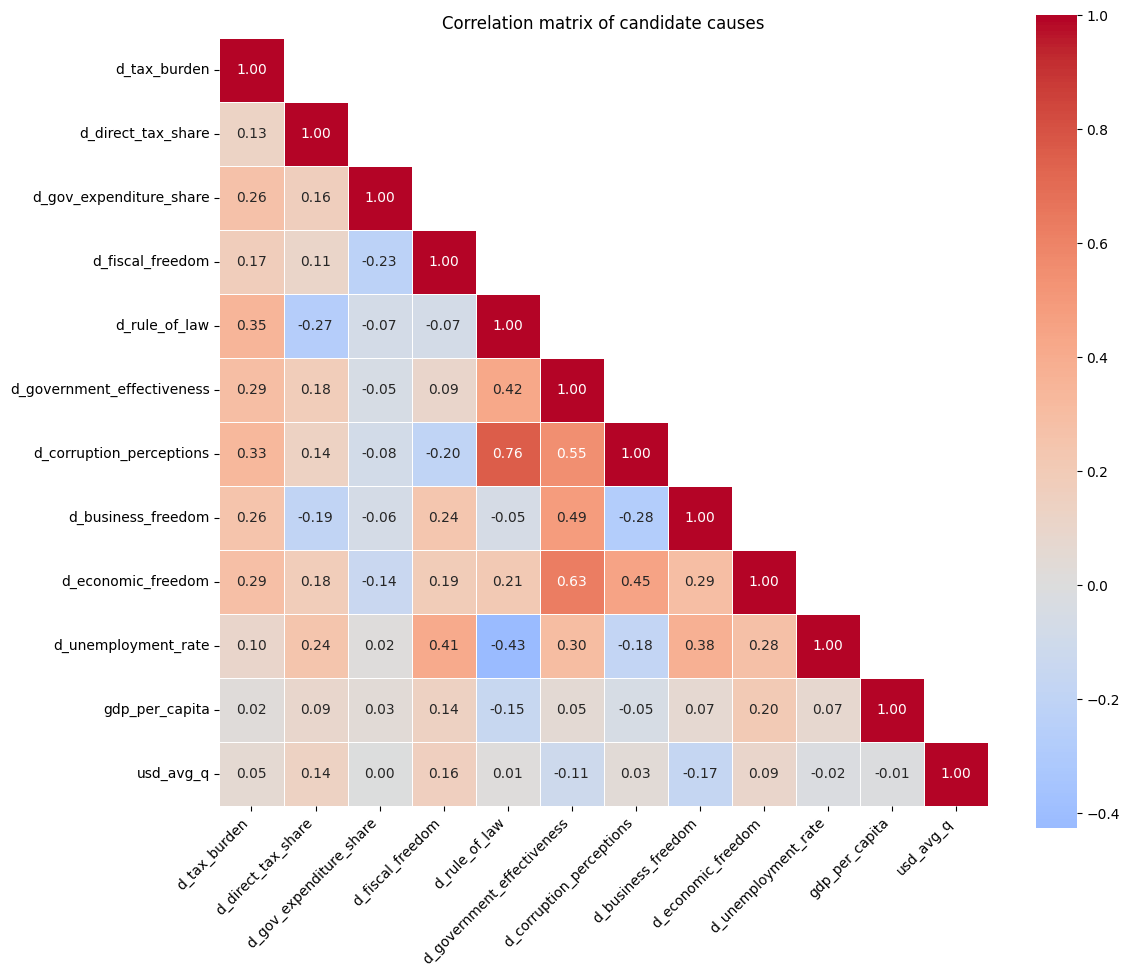

In [35]:
candidate_causes = [
    "d_tax_burden",
    "d_direct_tax_share",
    "d_gov_expenditure_share",
    "d_fiscal_freedom",
    "d_rule_of_law",
    "d_government_effectiveness",
    "d_corruption_perceptions",
    "d_business_freedom",
    "d_economic_freedom",
    "d_unemployment_rate",
    "gdp_per_capita", 
    "usd_avg_q"
]

df_plot = gold[candidate_causes].copy()
corr_matrix = df_plot.corr()

plt.figure(figsize=(12, 10))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Correlation matrix of candidate causes")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
gold.to_csv('data/final_data.csv')